### Importing Libraries

GPU Usage?

In [1]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("TensorFlow is using the GPU!")

    gpus = tf.config.list_physical_devices('GPU')
    print("Available GPUs:", gpus)

    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print("GPU Details:", details)
else:
    print("TensorFlow is using the CPU.")

TensorFlow is using the CPU.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
from tensorflow.keras.models import load_model

MODEL_PATH = '/content/drive/MyDrive/MINOR_PROJECT__Pneumonia_X_Ray/pneumonia_model.h5'


if os.path.exists(MODEL_PATH):
    model = load_model(MODEL_PATH)
    print("Model loaded successfully")
else:
    print("Model not found! Check the path.")

Mounted at /content/drive


Model loaded successfully


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
import os

# Pneumonia Data___Set


In [ ]:
labels = ['PNEUMONIA','NORMAL']
img_resize = 150

def get_data(dir):
    data = []
    for label in labels:
        path = os.path.join(dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                if img.endswith('jpeg'):
                    img_arr = cv2.imread(os.path.join(path,img), cv2.IMREAD_GRAYSCALE)
                    resized_arr = cv2.resize(img_arr, (img_resize, img_resize))
                    data.append([resized_arr, class_num])
            except Exception as e:
                print(e)
    return np.array(data,dtype= 'object')


In [ ]:
train = get_data("/content/drive/MyDrive/MINOR_PROJECT__Pneumonia_X_Ray/ChestXRay_DataSet/chest_xray/train")
val  = get_data("/content/drive/MyDrive/MINOR_PROJECT__Pneumonia_X_Ray/ChestXRay_DataSet/chest_xray/val")
test  = get_data("/content/drive/MyDrive/MINOR_PROJECT__Pneumonia_X_Ray/ChestXRay_DataSet/chest_xray/test")

In [ ]:
def count_images(dataset, name):

    pneumonia = 0
    normal = 0

    for i in dataset:
        if i[1] == 0:
            pneumonia += 1
        else:
            normal += 1

    total = pneumonia + normal

    print(f"\n{name} DATASET:")
    print("Total images:", total)
    print("PNEUMONIA images:", pneumonia)
    print("NORMAL images:", normal)


count_images(train, "TRAIN")
count_images(val, "VALIDATION")
count_images(test, "TEST")


TRAIN DATASET:
Total images: 5138
PNEUMONIA images: 3792
NORMAL images: 1346

VALIDATION DATASET:
Total images: 16
PNEUMONIA images: 8
NORMAL images: 8

TEST DATASET:
Total images: 624
PNEUMONIA images: 390
NORMAL images: 234


## Data Visualization && Preprocessing

<Axes: xlabel='count'>

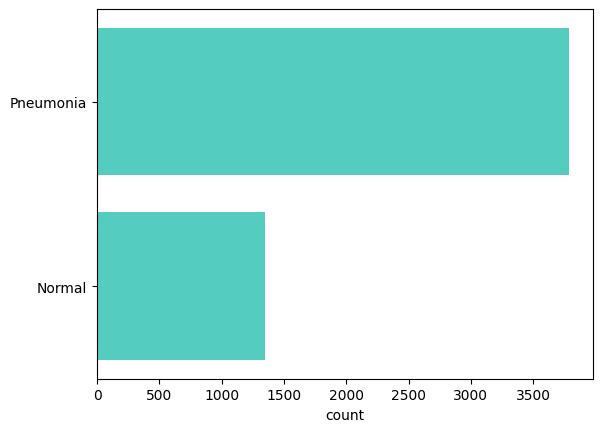

In [ ]:
l = []
for i in train:
    if (i[1] == 0):
        l.append('Pneumonia')
    else:
        l.append('Normal')

sns.countplot(y=l, color='#40E0D0')

Text(0.5, 1.0, 'NORMAL')

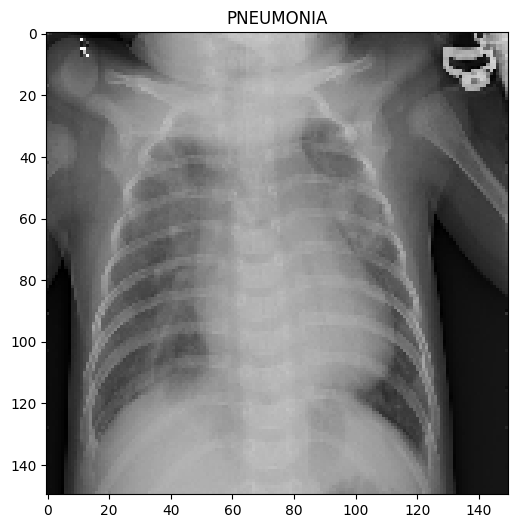

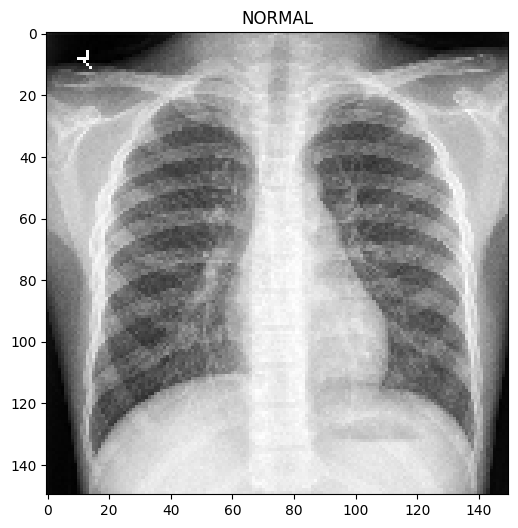

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))
plt.imshow(train[-11][0], cmap='gray')
plt.title(labels[train[-11][1]])

In [ ]:
x_train = []
y_train = []
for feat, label in train:
    x_train.append(feat)
    y_train.append(label)


x_val = []
y_val = []
for feat,label in val:
    x_val.append(feat)
    y_val.append(label)


x_test = []
y_test = []
for feat, label in test:
    x_test.append(feat)
    y_test.append(label)


## Normalizing       data ........

In [ ]:
#Normalizing.... data
# for reducing computation....
x_train = np.array(x_train)/255
x_val = np.array(x_val)/255
x_test = np.array(x_test)/255

# suitable for CNN

In [ ]:
x_train = x_train.reshape(-1,img_resize, img_resize,1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1,img_resize,img_resize,1)
y_val = np.array(y_val)


x_test = x_test.reshape(-1,img_resize,img_resize,1)
y_test = np.array(y_test)

# data augmentation

In [ ]:

data__gen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,


    rotation_range=30,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.2,
    horizontal_flip=True,
    vertical_flip=False
)

data__gen.fit(x_train)

## Train........

In [ ]:
model = Sequential()


# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    strides=1,
    padding='same',
    activation='relu',
    input_shape=(150,150,1)
))

model.add(BatchNormalization())

model.add(MaxPool2D(
    (2,2),
    strides=2,
    padding='same'
))



# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    strides=1,
    padding='same',
    activation='relu'
))

model.add(Dropout(0.1))

model.add(BatchNormalization())

model.add(MaxPool2D(
    (2,2),
    strides=2,
    padding='same'
))




# Third Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    strides=1,
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())

model.add(MaxPool2D(
    (2,2),
    strides=2,
    padding='same'
))




# Fourth Convolution Layer
model.add(Conv2D(
    128,
    (3,3),
    strides=1,
    padding='same',
    activation='relu'
))

model.add(Dropout(0.2))

model.add(BatchNormalization())

model.add(MaxPool2D(
    (2,2),
    strides=2,
    padding='same'
))




# Fifth Convolution Layer
model.add(Conv2D(
    256,
    (3,3),
    strides=1,
    padding='same',
    activation='relu'
))

model.add(Dropout(0.2))

model.add(BatchNormalization())

model.add(MaxPool2D(
    (2,2),
    strides=2,
    padding='same'
))




# Flatten Layer
model.add(Flatten())



# Dense Layer
model.add(Dense(
    units=128,
    activation='relu'
))

model.add(Dropout(0.2))




# Output Layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))




# Compile Model
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [ ]:
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    verbose=1,
    factor=0.3,
    min_lr=0.000001
)


In [ ]:
checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history = model.fit(
    x_train,
    y_train,
    batch_size=16,
    epochs=36,
    validation_data=data__gen.flow(x_val, y_val),
    callbacks=[learning_rate_reduction, checkpoint]
)

Epoch 1/36
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9978 - loss: 0.0035
Epoch 1: val_accuracy did not improve from 0.68750
322/322 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9978 - loss: 0.0035 - val_accuracy: 0.6250 - val_loss: 5.7960 - learning_rate: 1.0000e-06
Epoch 2/36
  1/322 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 1.0000 - loss: 7.6155e-06

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


319/322 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9997 - loss: 0.0018
Epoch 2: val_accuracy did not improve from 0.68750
322/322 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9997 - loss: 0.0018 - val_accuracy: 0.6875 - val_loss: 5.8165 - learning_rate: 1.0000e-06
Epoch 3/36
319/322 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9969 - loss: 0.0044
Epoch 3: val_accuracy did not improve from 0.68750
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9969 - loss: 0.0044 - val_accuracy: 0.5625 - val_loss: 8.0989 - learning_rate: 1.0000e-06
Epoch 4/36
320/322 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9994 - loss: 0.0041
Epoch 4: val_accuracy did not improve from 0.68750
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9994 - loss: 0.0041 - val_accuracy: 0.5000 - val_loss: 8.1494 - learning_rate: 1.0000e-06
Epoch 5/36
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9990 - loss: 0.0025
Epoch 5: val_accuracy did not improve from 0.68750
322/322 ━━━━━━━━━━━━━

In [ ]:
model.save(MODEL_PATH)
print("Model saved successfully in Drive")

Model saved successfully in Drive


In [ ]:
model.evaluate(x_test,y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9240 - loss: 1.0791


[3.7671477794647217, 0.7403846383094788]

In [ ]:

print(f"Loss of the model is {model.evaluate(x_test,y_test)[0]}")
print(f"Accuracy of the model is {model.evaluate(x_test,y_test)[1]*100} %")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9240 - loss: 1.0791
Loss of the model is 3.7671477794647217
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9240 - loss: 1.0791
Accuracy of the model is 74.03846383094788 %


# Analyse Model Performance

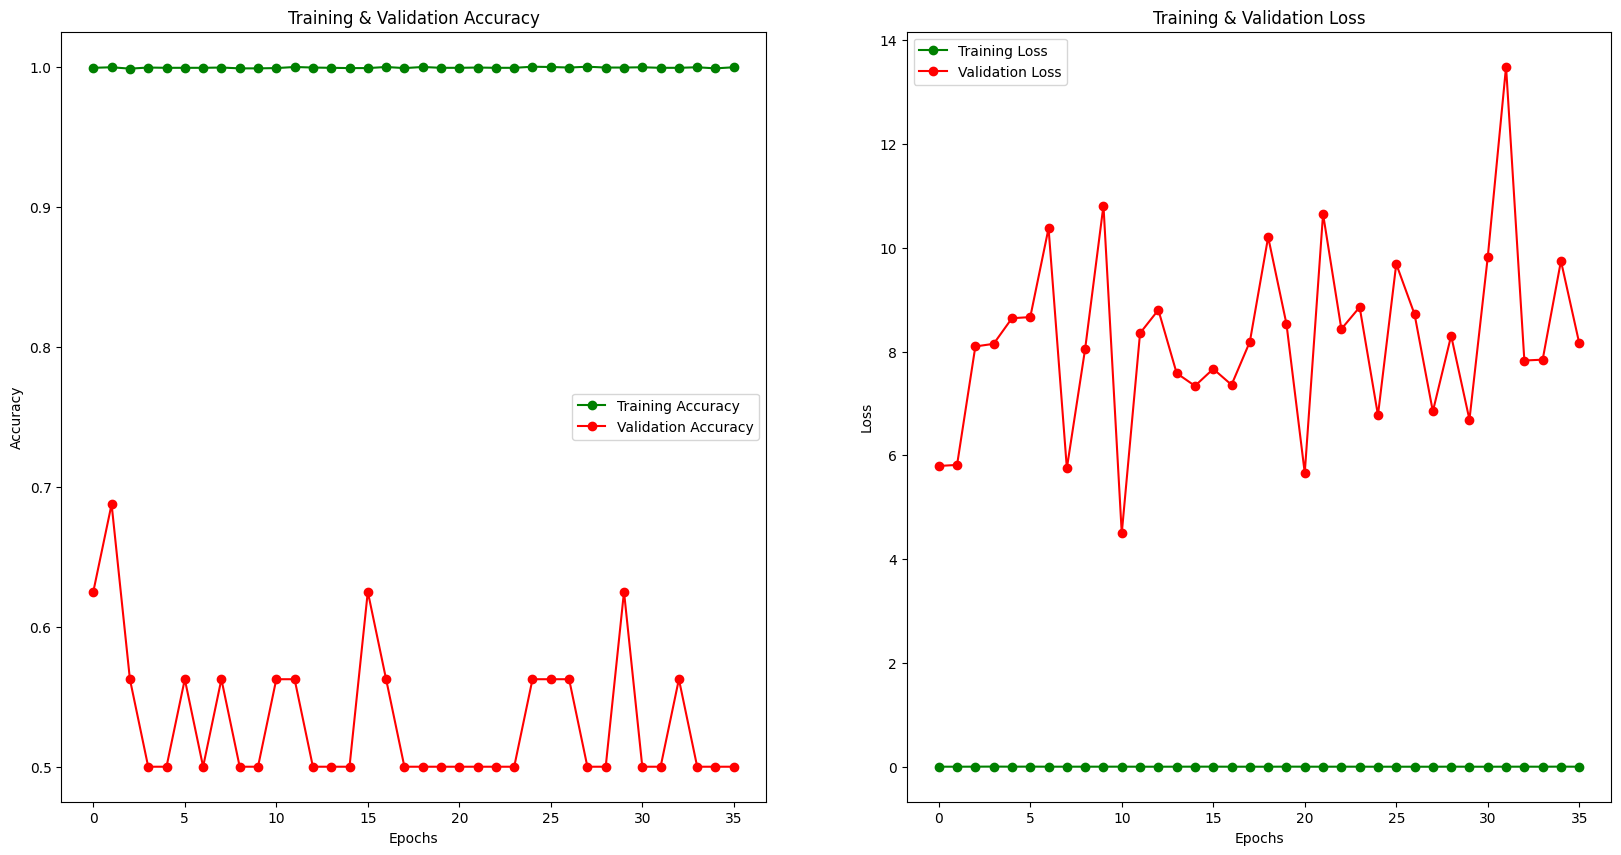

In [ ]:
epochs = [i for i in range(36)]
fig, ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.set_size_inches(20,10)

ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')


ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
plt.show()

In [ ]:
predictions = (model.predict(x_test) > 0.5).astype('int32')
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [ ]:
print(classification_report(y_test, predictions, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))


                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.71      1.00      0.83       390
   Normal (Class 1)       1.00      0.31      0.47       234

           accuracy                           0.74       624
          macro avg       0.85      0.65      0.65       624
       weighted avg       0.82      0.74      0.69       624



In [ ]:


cm = confusion_matrix(y_test,predictions)

In [ ]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

<Axes: >

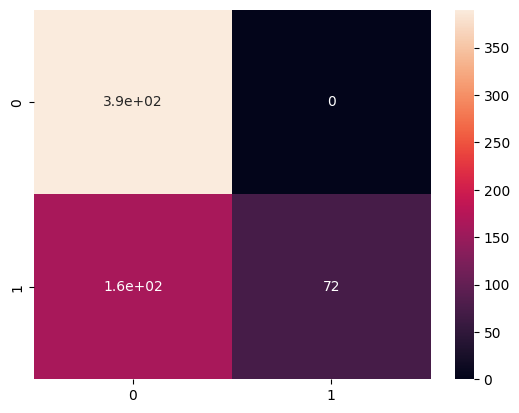

In [ ]:
sns.heatmap(cm, annot=True)

#Some correctly Predicted Classes---->>>

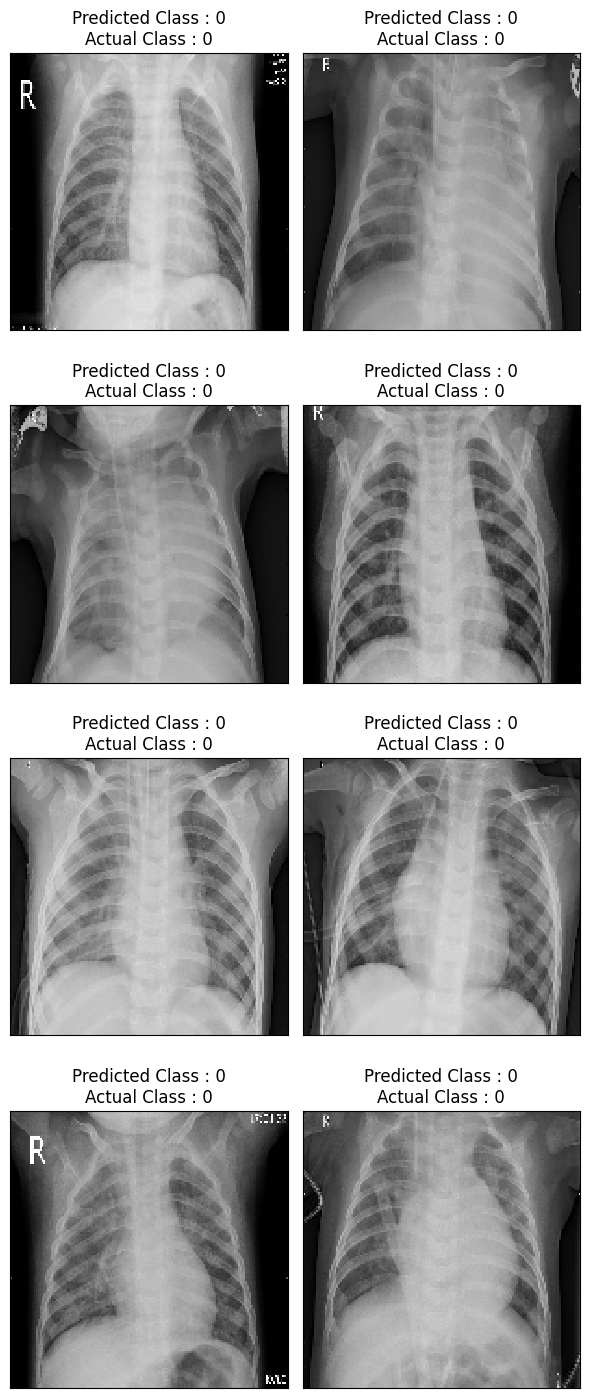

In [ ]:

i = 0
plt.figure(figsize=(6,15))
for c in correct[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1

#Some incorrectly Predicted Classes____>>>

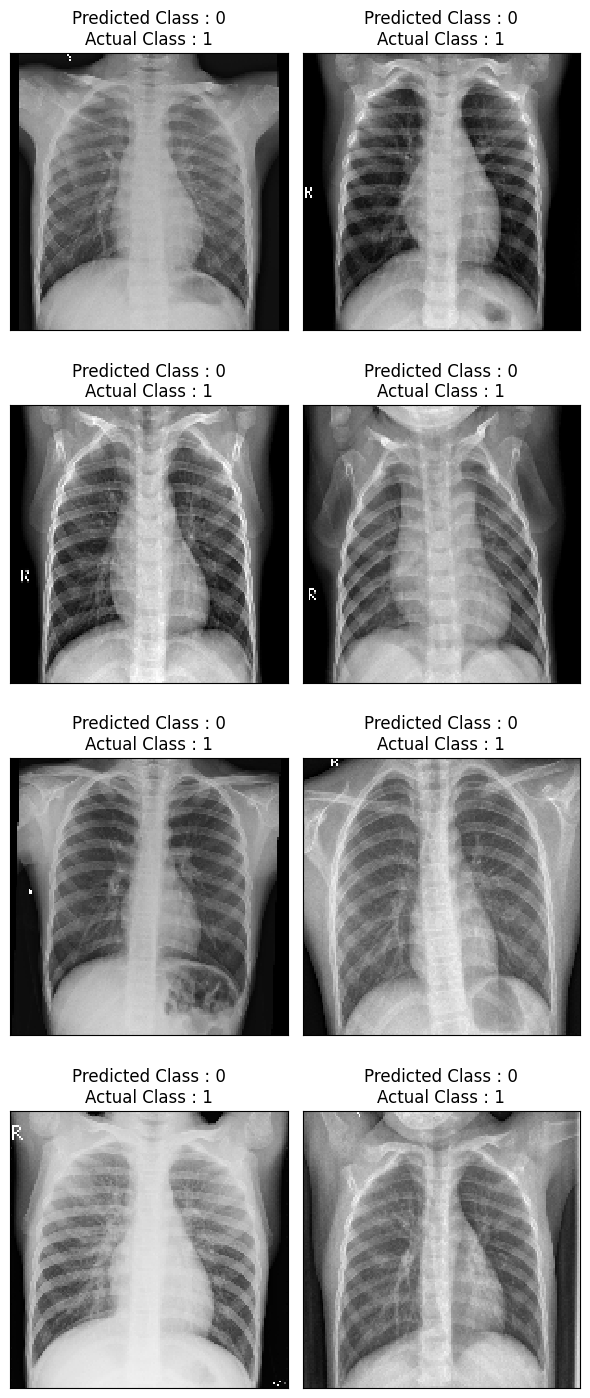

In [ ]:
# //for incorrect predicted classes hum normal ko Penumonia dekha
# sakte hai but not vice versa........

i = 0
plt.figure(figsize=(6,15))
for c in incorrect[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1